In [21]:
import h5py
import numpy as np
import pygmt
import xarray as xr

In [22]:
with h5py.File("OUTPUT_FILES/initial_model.h5", "r") as f:
    initial_vs = f["vs"][:]

with h5py.File("OUTPUT_FILES/final_model.h5", "r") as f:
    x = f["x"][:]
    y = f["y"][:]
    z = f["z"][:]
    final_vs = f["vs"][:]

with h5py.File("OUTPUT_FILES/target_model.h5", "r") as f:
    target_vs = f["vs"][:]

dv = (final_vs - initial_vs) / initial_vs * 100
dvt = (target_vs - initial_vs) / initial_vs * 100

In [23]:
def _validate_model_field(vs_field, x, y, z):
    """Validate that the model field uses the grid ordering (x, y, z)."""
    expected_shape = (len(x), len(y), len(z))
    if vs_field.shape != expected_shape:
        raise ValueError(
            f"Vs field shape {vs_field.shape} does not match {expected_shape}"
        )


def _to_vertical_section(data, horizontal_coordinate, z, coordinate_name):
    """Convert a horizontal/depth array to a vertical-section DataArray."""
    return xr.DataArray(
        data.T,
        coords={"depth": z, coordinate_name: horizontal_coordinate},
        dims=("depth", coordinate_name),
        name="Vs perturbation",
    )


def plot_horizontal_slices(
    vs_field,
    model_name,
    x,
    y,
    z,
    depths=(3.5, 11.0),
    region=(102, 104, 24, 26),
    panel_size=("6c", "7c"),
    spacing="0.01/0.01",
    cpt_series=(-8, 8, 0.1),
):
    """Plot horizontal Vs-perturbation slices in a single row."""
    _validate_model_field(vs_field, x, y, z)
    slice_indices = [
        int(np.abs(z - requested_depth).argmin())
        for requested_depth in depths
    ]
    xx, yy = np.meshgrid(x, y, indexing="ij")
    grids = []
    for depth_index in slice_indices:
        grids.append(
            pygmt.surface(
                x=xx.ravel(),
                y=yy.ravel(),
                z=vs_field[:, :, depth_index].ravel(),
                region=region,
                spacing=spacing,
            )
        )

    fig = pygmt.Figure()
    pygmt.makecpt(
        cmap="vik",
        series=cpt_series,
        background=True,
        continuous=True,
    )
    with pygmt.config(
        MAP_FRAME_TYPE="plain",
        FONT_HEADING="13p,Helvetica-Bold",
        FONT_ANNOT_PRIMARY="9p",
        FONT_LABEL="10p",
        MAP_HEADING_OFFSET="5p",
    ):
        with fig.subplot(
            nrows=1,
            ncols=len(slice_indices),
            subsize=panel_size,
            region=region,
            projection="M6c",
            frame=["WSen", "xa1f0.5", "ya1f0.5"],
            margins=("0.3c", "0c"),
            sharex="b",
            sharey="l",
            title=f"{model_name} isotropic model",
        ):
            for panel, (depth_index, grid) in enumerate(
                zip(slice_indices, grids)
            ):
                with fig.set_panel(panel=panel):
                    fig.grdimage(grid, cmap=True)
                    fig.text(
                        x=region[0],
                        y=region[2],
                        text=f"Depth = {z[depth_index]:.1f} km",
                        no_clip=True,
                        justify="BL",
                        font="9p,Helvetica-Oblique",
                        offset="0.12c/0.12c",
                        fill="white@55",
                        pen="0.2p,gray50@55",
                    )

            fig.colorbar(
                position="x-0.3c/-1c+w7c/0.3c+h+jTC",
                frame=["xa4f1+lVs perturbation (%)"],
            )
    return fig


def plot_vertical_slices(
    vs_field,
    model_name,
    x,
    y,
    z,
    latitude=None,
    longitude=102.6,
    panel_size=("6c", "3.8c"),
    projection="X6c/-3.5c",
    cpt_series=(-8, 8, 0.1),
):
    """Plot constant-latitude and constant-longitude vertical slices."""
    _validate_model_field(vs_field, x, y, z)
    iy = (
        len(y) // 2
        if latitude is None
        else int(np.abs(y - latitude).argmin())
    )
    ix = int(np.abs(x - longitude).argmin())
    longitude_section = _to_vertical_section(
        vs_field[:, iy, :], x, z, "longitude"
    )
    latitude_section = _to_vertical_section(
        vs_field[ix, :, :], y, z, "latitude"
    )
    longitude_region = [x.min(), x.max(), z.min(), z.max()]
    latitude_region = [y.min(), y.max(), z.min(), z.max()]

    fig = pygmt.Figure()
    pygmt.makecpt(
        cmap="vik",
        series=cpt_series,
        background=True,
        continuous=True,
    )
    with pygmt.config(
        MAP_FRAME_TYPE="plain",
        FONT_HEADING="13p,Helvetica-Bold",
        FONT_ANNOT_PRIMARY="9p",
        FONT_LABEL="10p",
        MAP_HEADING_OFFSET="5p",
    ):
        with fig.subplot(
            nrows=1,
            ncols=2,
            subsize=panel_size,
            margins=("0.35c", "0c"),
            title=f"{model_name} Cross-section",
        ):
            with fig.set_panel(panel=0):
                fig.grdimage(
                    longitude_section,
                    cmap=True,
                    region=longitude_region,
                    projection=projection,
                    frame=[
                        "WSen",
                        "xa0.5f0.25+lLongitude (@.)",
                        "ya2f1+lDepth (km)",
                    ],
                )
                fig.text(
                    x=longitude_region[0],
                    y=longitude_region[3],
                    text=f"Latitude = {y[iy]:.2f}@.",
                    no_clip=True,
                    justify="BL",
                    font="9p,Helvetica-Oblique",
                    offset="0.12c/0.12c",
                    fill="white@55",
                    pen="0.2p,gray50@55",
                )

            with fig.set_panel(panel=1):
                fig.grdimage(
                    latitude_section,
                    cmap=True,
                    region=latitude_region,
                    projection=projection,
                    frame=[
                        "wSen",
                        "xa0.5f0.25+lLatitude (@.)",
                        "ya2f1",
                    ],
                )
                fig.text(
                    x=latitude_region[0],
                    y=latitude_region[3],
                    text=f"Longitude = {x[ix]:.2f}@.",
                    no_clip=True,
                    justify="BL",
                    font="9p,Helvetica-Oblique",
                    offset="0.12c/0.12c",
                    fill="white@55",
                    pen="0.2p,gray50@55",
                )

            fig.colorbar(
                position="x-0.35c/-1.5c+w7c/0.25c+h+jTC",
                frame=["xa4f1+lVs perturbation (%)"],
            )
    return fig

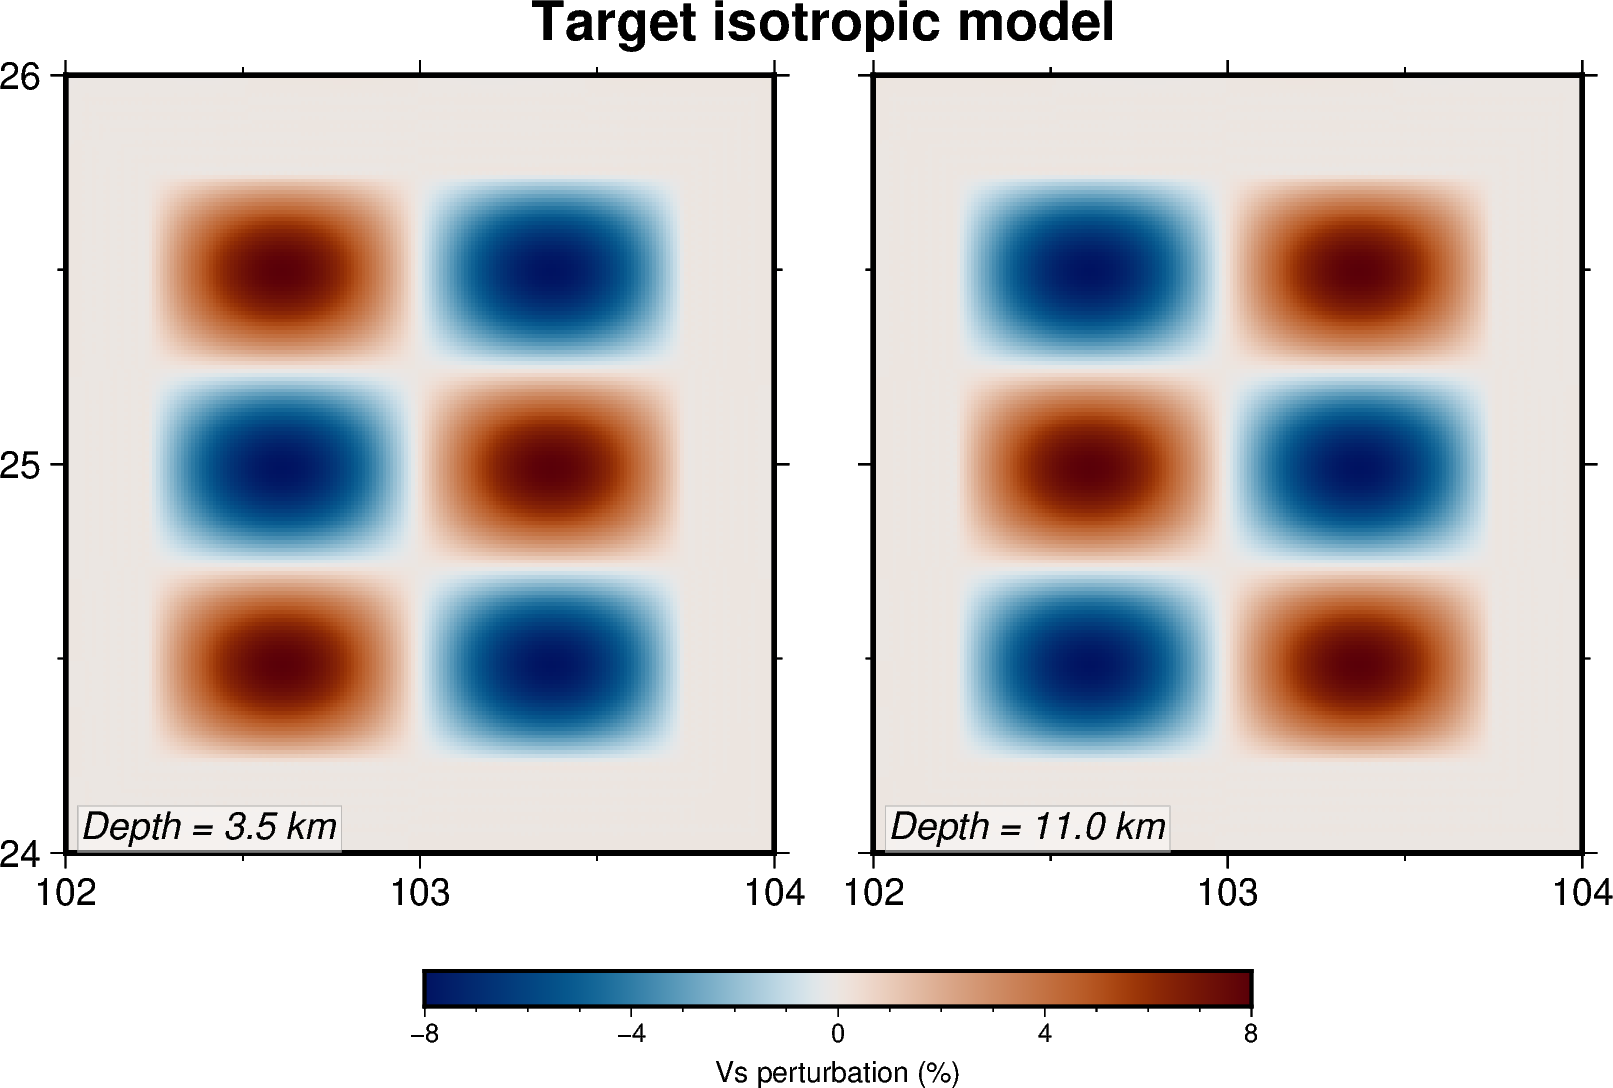

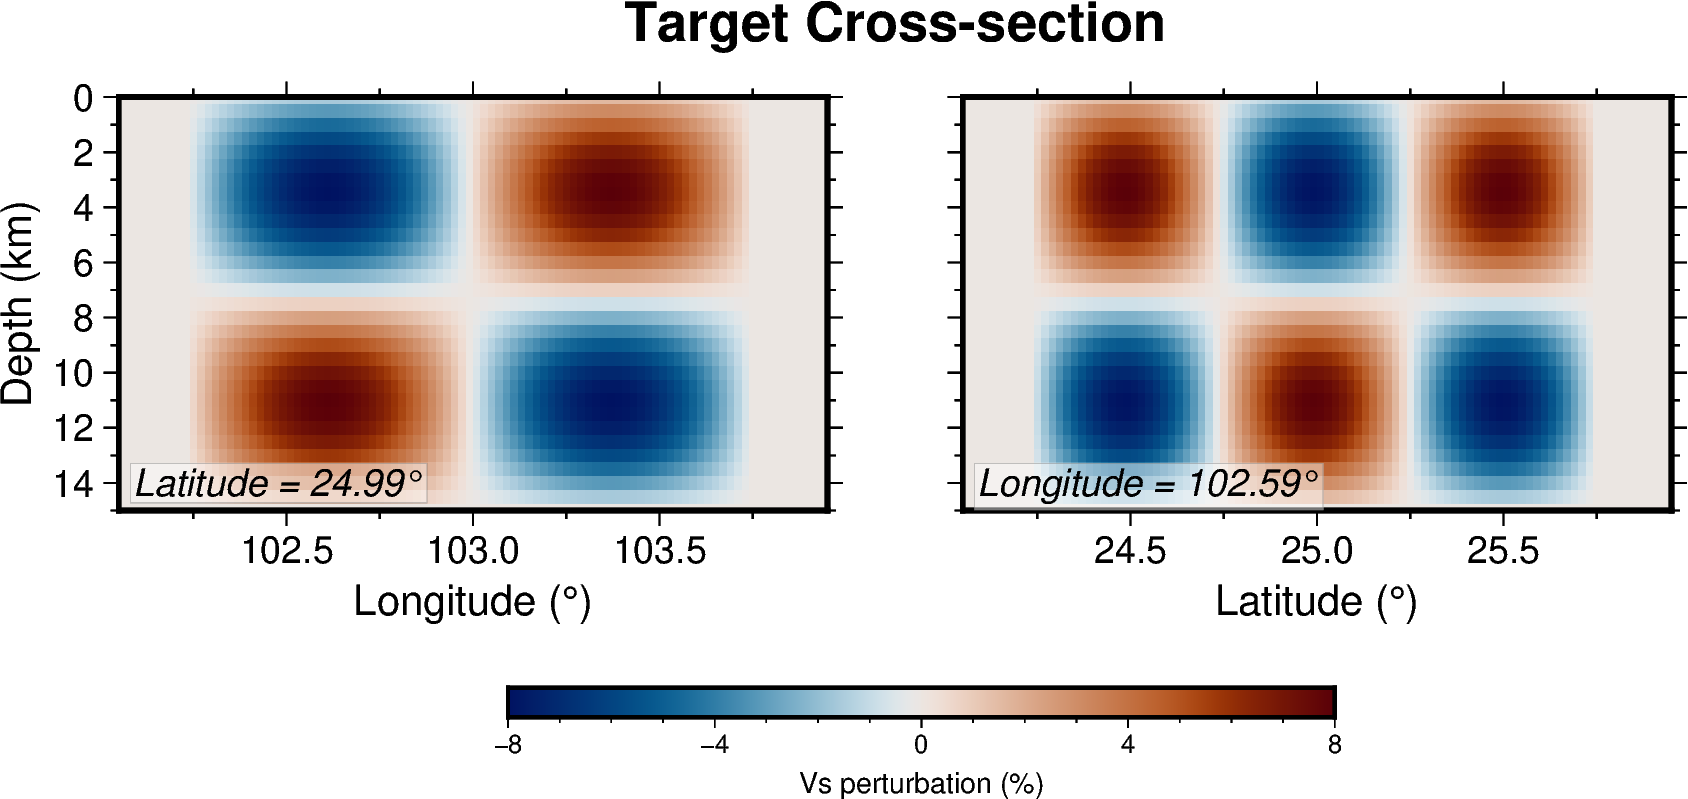

In [24]:
# Plot the true model
true_horizontal = plot_horizontal_slices(
    dvt,
    "Target",
    x,
    y,
    z,
)
true_vertical = plot_vertical_slices(
    dvt,
    "Target",
    x,
    y,
    z,
    latitude=25.0,
    longitude=102.6,
)
true_horizontal.show()
true_vertical.show()

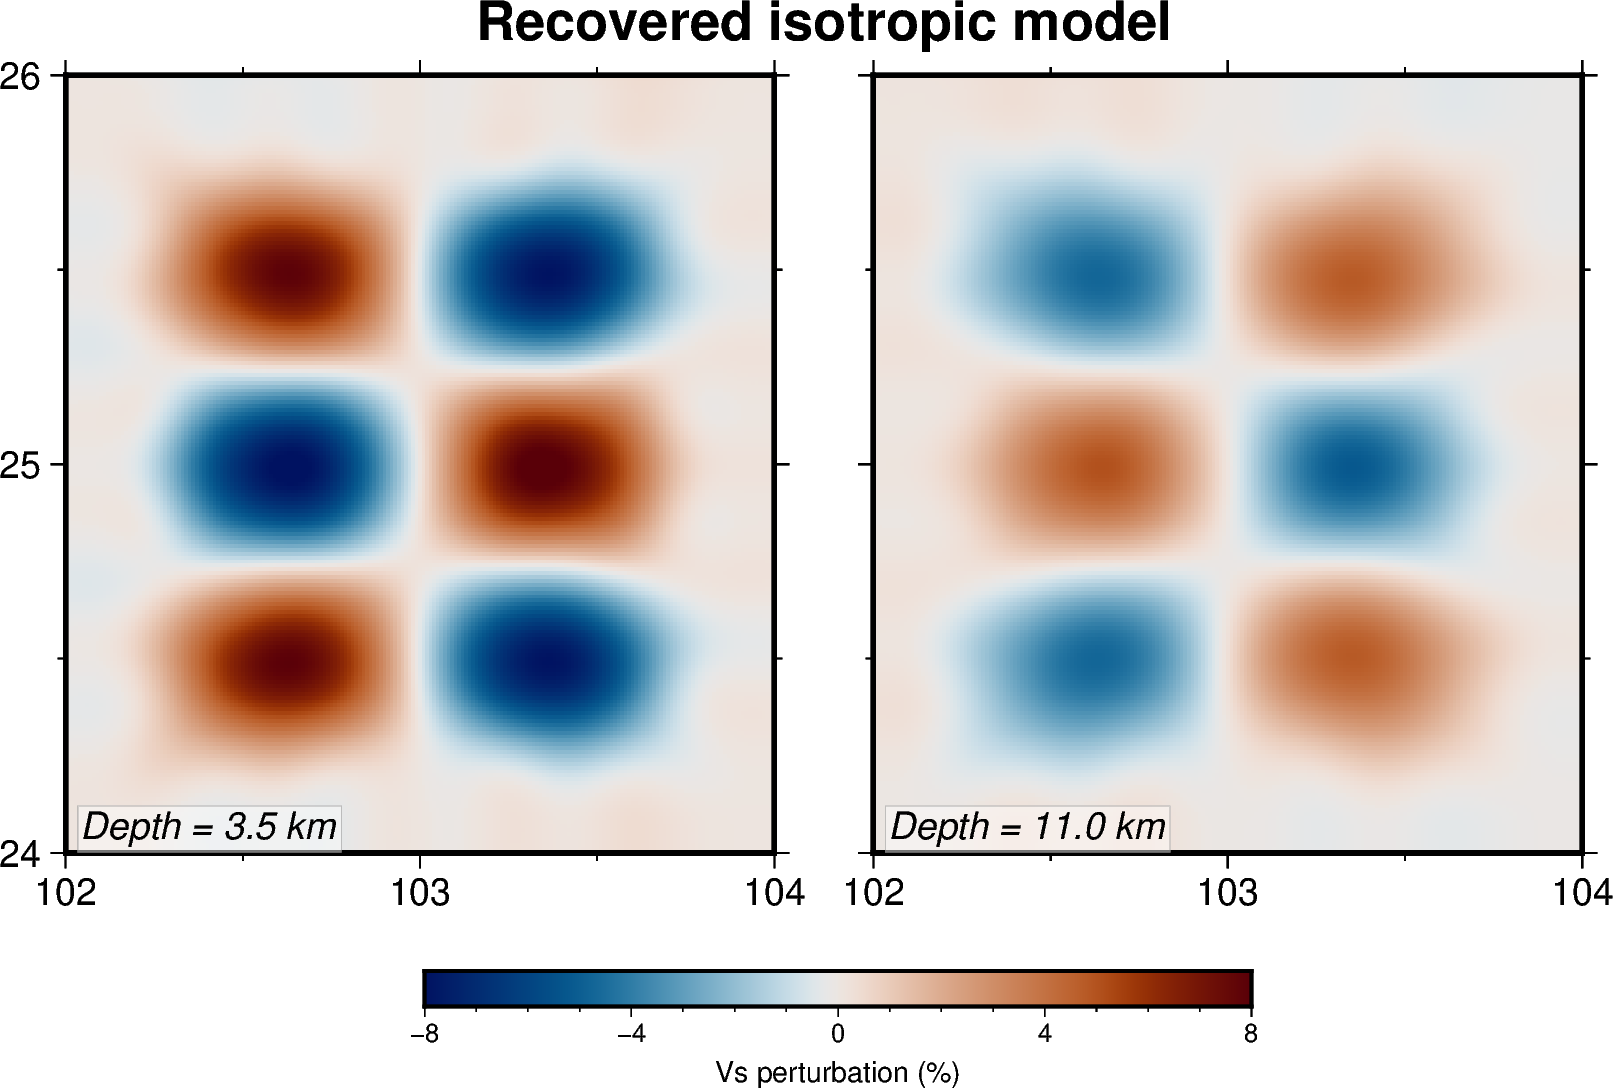

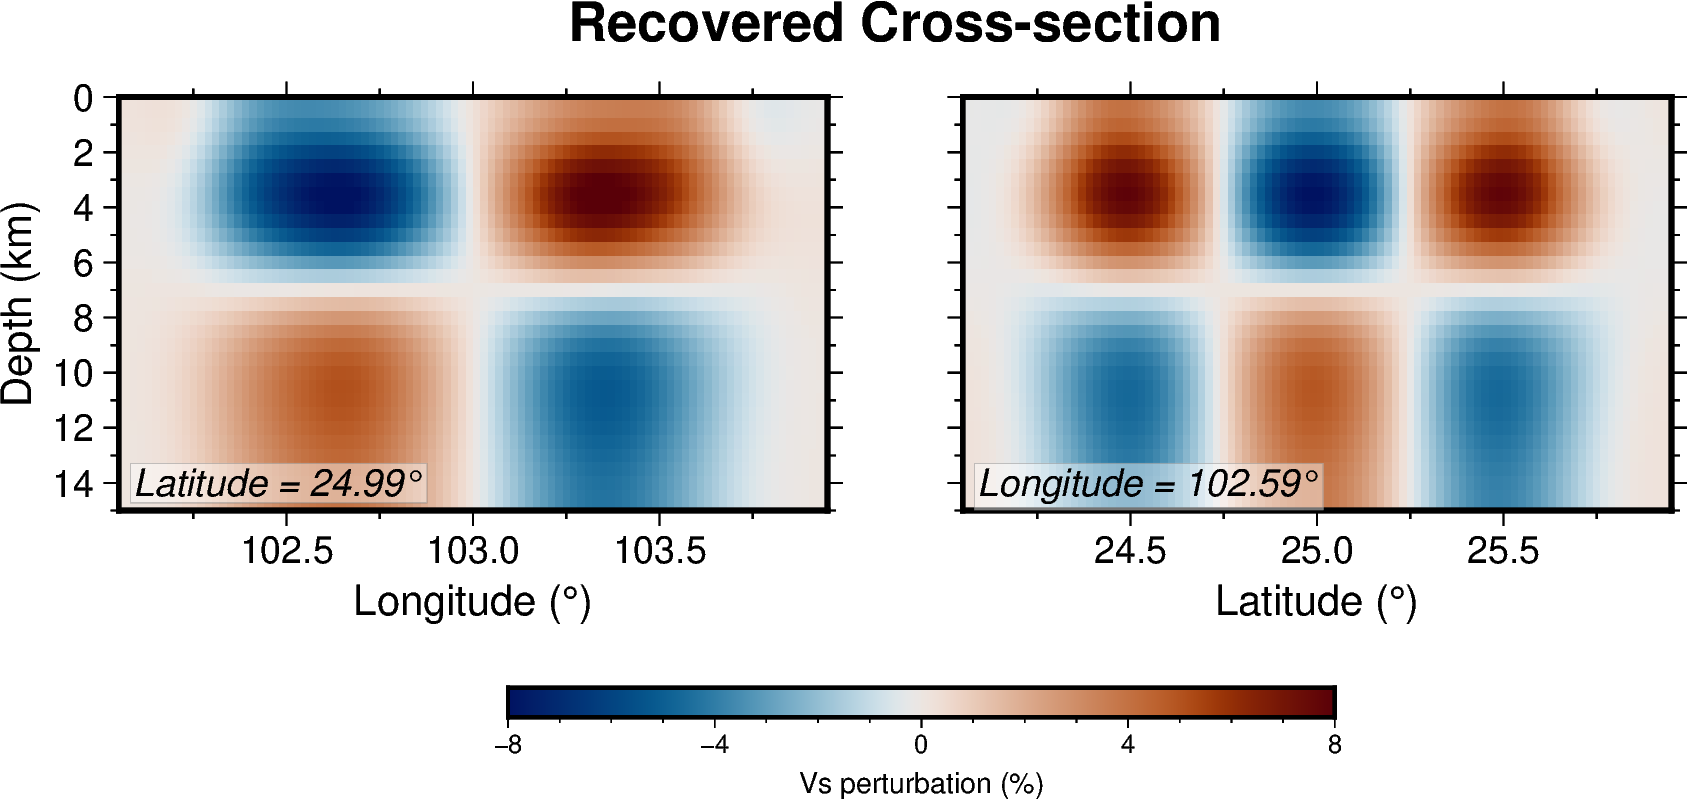

In [25]:
# Plot the inversion result with the same plotting functions
result_horizontal = plot_horizontal_slices(
    dv,
    "Recovered",
    x,
    y,
    z,
)
result_vertical = plot_vertical_slices(
    dv,
    "Recovered",
    x,
    y,
    z,
    latitude=25.0,
    longitude=102.6,
)
result_horizontal.show()
result_vertical.show()